# Dados desbalanceados

Neste notebook vamos construir e avaliar um detector de fraude em um conjunto de dados reais de transações de cartão de crédito. Os dados são baixados de:

https://www.openml.org/d/1597

São transações feitas por portadores de cartão europeus em dois dias de setembro de 2013. Cada linha é uma transação. As colunas são:

- `V1` a `V28`: componentes principais obtidos por PCA, um método de redução de dimensionalidade, sobre os atributos originais. As colunas originais não foram divulgadas por sigilo bancário
- `Amount`: valor da transação
- `Class`: 1 se a transação é fraude, 0 caso contrário

O objetivo é praticar as três ferramentas da aula: **escolha do limiar**, **calibração** e **ponderação da função de perda**.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Carregando os dados

Podemos carregar os dados diretamente do OpenML usando a função `fetch_openml` do `sklearn.datasets`. 

In [2]:
from sklearn.datasets import fetch_openml

# O arquivo tem cerca de 68 MB, então o download demora alguns minutos na primeira execução. 
data = fetch_openml(data_id=1597, as_frame=True)
df = data.frame

# Se o OpenML estiver fora do ar, use a cópia local:
# df = pd.read_parquet("../dados/creditcard.parquet")

df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
df.shape

(284807, 30)

## A taxa base

A primeira coisa a olhar em um problema de classificação é a proporção de cada classe.

In [4]:
# A coluna Class vem como categoria de texto ('0' e '1')
y = df["Class"].astype(int).to_numpy()

# Todas as outras colunas são atributos
X = df.drop(columns="Class")
mean = y.mean()

print(f"transações: {len(y)}")
print(f"fraudes:    {y.sum()}")
print(f"taxa base:  {100*mean:.3f}%")
print(f"1 fraude a cada {round(1/mean)} transações")

transações: 284807
fraudes:    492
taxa base:  0.173%
1 fraude a cada 579 transações


Os dois números que descrevem o desbalanceamento:

- a **razão** entre as classes é de 1 para 579,
- o **número absoluto** de positivos é 492.

O segundo é o que costuma atrapalhar. Como veremos adiante, 492 fraudes divididas entre treino, validação e teste deixam pouca margem para estimar com precisão.

### O valor das transações

A coluna `Amount` possui o valor das transações.

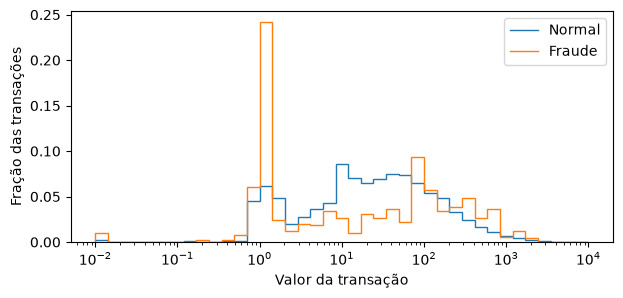

In [5]:
fig, ax = plt.subplots(figsize=(7, 3))

# Os valores variam de centavos a milhares de euros, então usamos faixas em escala log.
# Caixas de 10^-2 (1 centavo) a 10^4 (10.000 euros), com 40 caixas no total.
bins = np.logspace(-2, 4, 40)
for idx, label in enumerate(["Normal", "Fraude"]):
    values = X.loc[y==idx, "Amount"]
    hist, _ = np.histogram(values, bins=bins)
    # Cada classe é normalizada pelo seu tamanho, senão as fraudes sumiriam.
    ax.stairs(hist/len(values), bins, label=label)

ax.set_xscale("log")
ax.set_xlabel("Valor da transação")
ax.set_ylabel("Fração das transações")
ax.legend()
plt.show()

O histograma mostra um pico em 1 euro para fraudes, uma concentração que não existe entre as transações normais.

Isso é conhecido no setor. Quem testa um cartão roubado costuma começar com uma compra mínima, só para descobrir se o cartão ainda está ativo, antes de tentar algo maior.

## Treino, validação e teste

Nas aulas anteriores dividimos os dados em duas partes. Aqui precisamos de três.

O motivo é que o limiar de decisão e a calibração são **escolhidos** a partir dos dados, exatamente como os parâmetros do modelo. Se escolhermos o limiar olhando o conjunto de teste e depois reportarmos o desempenho nesse mesmo conjunto, o resultado sai otimista.

- **treino**: ajusta os parâmetros do modelo,
- **validação**: escolhe o limiar e ajusta a calibração,
- **teste**: mede o desempenho final, e é usado uma vez só.

In [6]:
from sklearn.model_selection import train_test_split

# Divisão entre treino/validação e teste, com 30% das transações reservadas para teste.
# stratify mantém a mesma proporção de fraudes em cada parte
X_dev, X_test, y_dev, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=0)

# Divisão entre treino e validação
X_train, X_val, y_train, y_val = train_test_split(
    X_dev, y_dev, test_size=0.25, stratify=y_dev, random_state=0)

for name, part in [("treino", y_train), ("validação", y_val), ("teste", y_test)]:
    print(f"{name}: {part.sum()} fraudes em {len(part)} transações")

treino: 258 fraudes em 149523 transações
validação: 86 fraudes em 49841 transações
teste: 148 fraudes em 85443 transações


## A armadilha da acurácia

Um classificador que prevê "não é fraude" para toda transação automaticamente possui alta acurácia.

In [7]:
from sklearn.metrics import accuracy_score

# prevê "não é fraude" para toda transação
y_pred = np.zeros_like(y_test)
print(f"acurácia: {accuracy_score(y_test, y_pred)}")

acurácia: 0.9982678510820079


99,8% de acurácia sem olhar para nenhuma coluna. Em dados desbalanceados a acurácia raramente informa alguma coisa.

## Um primeiro modelo

Usaremos regressão logística como classificador. O funcionamento dela é assunto da disciplina de aprendizado de máquina.

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
model.fit(X_train, y_train);

In [9]:
# predict_proba retorna, em cada linha i, dois valores (A, B), onde A é a probabilidade de ser 
# da classe negativa e B é a probabilidade de ser da classe positiva (fraude). 
scores_val = model.predict_proba(X_val)
print(scores_val[0])

[9.99798308e-01 2.01691630e-04]


In [10]:
# Usaremos apenas os valores B, pois é garantido que A + B = 1.0. Portanto, A = 1 - B e os 
# dois valores são redundantes. 
scores_val = model.predict_proba(X_val)[:, 1]
scores_test = model.predict_proba(X_test)[:, 1]

print(scores_test.min(), scores_test.max())

5.865980793864758e-12 0.9999999998776072


In [11]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score

# O .predict do scikit-learn usa limiar 0.5, então fazemos a comparação explicitamente
y_pred = (scores_test >= 0.5).astype(int)

print(confusion_matrix(y_test, y_pred))
print(f"precisão:  {precision_score(y_test, y_pred):.3f}")
print(f"revocação: {recall_score(y_test, y_pred):.3f}")

[[85280    15]
 [   57    91]]
precisão:  0.858
revocação: 0.615


Das transações que o modelo acusou, 86% eram mesmo fraude. Mas das 148 fraudes do conjunto de teste ele encontrou apenas 91. Deixou 57 passarem.

Precisão alta e revocação baixa é o comportamento esperado do limiar 0.5 em dados desbalanceados: o modelo só acusa quando tem muita certeza.

## PR-AUC, ROC-AUC e Brier

Precisão e revocação dependem do limiar. Para resumir o modelo inteiro em um número, usamos a área sob uma das duas curvas.

In [12]:
from sklearn.metrics import average_precision_score, roc_auc_score, brier_score_loss

def score_summary(y_true, scores):
    """Resumo de métricas para um conjunto de scores."""

    metrics = {
        "PR-AUC": average_precision_score(y_true, scores),
        "ROC-AUC": roc_auc_score(y_true, scores),
        "Brier": brier_score_loss(y_true, scores)
    }

    return metrics

score_summary(y_test, scores_test)

{'PR-AUC': 0.7382256961669161,
 'ROC-AUC': 0.9641211027546687,
 'Brier': 0.0007291090998476775}

A ROC parece ótima porque a métrica considera verdadeiros negativos (`VN`), que são transações normais.

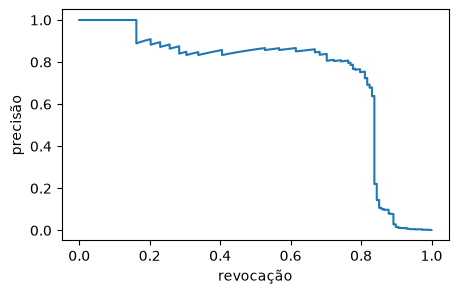

In [13]:
from sklearn.metrics import precision_recall_curve

prec, rec, _ = precision_recall_curve(y_test, scores_test)

fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(rec, prec)
ax.set_xlabel("revocação")
ax.set_ylabel("precisão")
plt.show()

## O limiar de decisão

Vamos ver como a precisão e a revocação mudam quando variamos o limiar de decisão. 

In [14]:
def threshold_report(y_true, scores, cuts):
    """Precisão, revocação e número de alarmes para uma lista de limiares."""
    rows = []
    for cut in cuts:
        flagged = (scores >= cut).astype(int)
        rows.append({"limiar": cut,
                     "alarmes": flagged.sum(),
                     "precisão": round(precision_score(y_true, flagged), 3),
                     "revocação": round(recall_score(y_true, flagged), 3)})
    return pd.DataFrame(rows)

threshold_report(y_test, scores_test, [0.5, 0.2, 0.1, 0.05, 0.02, 0.01])

,limiar,alarmes,precisão,revocação
0,0.50,106,0.858,0.615
1,0.20,130,0.808,0.709
2,0.10,139,0.806,0.757
3,0.05,155,0.761,0.797
4,0.02,205,0.605,0.838
5,0.01,318,0.390,0.838


### Escolha do limiar pelo custo

O critério mais comum é o custo de errar.

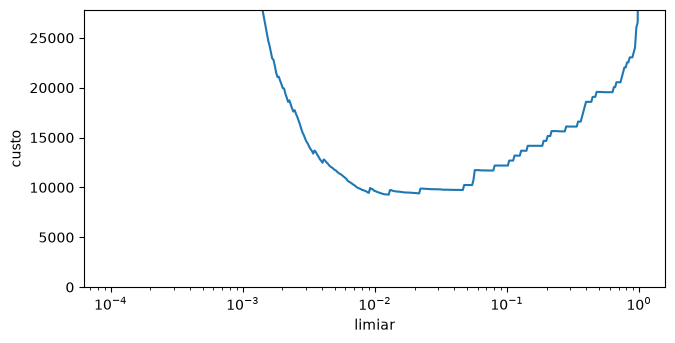

In [15]:
# Prejuízo médio de uma fraude não detectada, em euros
COST_FN = 500
# Custo de revisar um alarme falso, em euros
COST_FP = 10

def total_cost(y_true, y_pred, cost_fn=COST_FN, cost_fp=COST_FP):
    """Custo total de um conjunto de decisões, em euros. cost_fn  e cost_fp podem ser valores
    escalares ou vetores com o custo de cada previsão incorreta."""

    misses = (y_true == 1) & (y_pred == 0)
    false_alarms = (y_true == 0) & (y_pred == 1)
    # Cada fn recebe o custo correspondente
    cost_misses = np.where(misses, cost_fn, 0)
    # O mesmo para fp
    cost_false_alarms = np.where(false_alarms, cost_fp, 0)

    return np.sum(cost_misses) + np.sum(cost_false_alarms)

def cost_curve(y_true, scores, cuts, cost_fn=COST_FN, cost_fp=COST_FP):
    """Custo total para cada limiar."""
    
    costs = []
    for cut in cuts:
        cost = total_cost(y_true, scores >= cut, cost_fn, cost_fp)
        costs.append(cost)

    return np.array(costs)

# Os scores se concentram perto de zero, então um grid logarítmico coloca resolução
# onde ela é necessária. O grid vai até 1 porque modelos ponderados têm o ótimo no topo.
cuts = np.logspace(-4, 0, 400)

costs = cost_curve(y_val, scores_val, cuts)

fig, ax = plt.subplots(figsize=(7.5, 3.6))
ax.plot(cuts, costs)
ax.set_xscale("log")
ax.set_xlabel("limiar")
ax.set_ylabel("custo")
ax.set_ylim(0, 3*costs.min())
plt.show()

In [16]:
def best_threshold(y_true, scores, cuts, cost_fn=COST_FN, cost_fp=COST_FP):
    """Limiar do grid que produz o menor custo total."""
    costs = cost_curve(y_true, scores, cuts, cost_fn, cost_fp)
    idx_min = costs.argmin()
    return cuts[idx_min]

# O limiar é escolhido na validação, nunca no teste
cut_val = best_threshold(y_val, scores_val, cuts)

print(f"melhor limiar segundo a validação: {cut_val:.4f}")

melhor limiar segundo a validação: 0.0127


In [17]:
# Custo total no conjunto de teste, usando o limiar escolhido na validação
total_cost(y_test, scores_test > cut_val)

np.int64(13250)

### Quando cada erro custa um valor diferente

Até aqui toda fraude custou R\$ 500. Na prática o prejuízo é o valor da transação, que está na coluna `Amount`. A função `total_cost` já aceita um vetor de custos.

In [18]:
amount_val = X_val["Amount"].to_numpy()
cut_amount = best_threshold(y_val, scores_val, cuts, cost_fn=amount_val)
print(f"limiar com custo por linha: {cut_amount:.4f}")

limiar com custo por linha: 0.0414


O limiar mudou porque a matriz de custos mudou, e não porque o modelo mudou. Vale reforçar: o limiar pertence à decisão, não ao classificador. Um mesmo modelo pode operar com limiares diferentes em times diferentes da mesma empresa.

## Calibração

O método se chama `predict_proba`, mas o score que ele devolve não é necessariamente uma probabilidade. Para verificar, dividimos os scores em faixas e comparamos, em cada faixa, a média dos scores previstos com a fração real de fraudes.

In [19]:
def calibration_table(y_true, scores, n_bins=5):
    """Compara o score médio previsto com a frequência observada, faixa a faixa.

    strategy="quantile" usa faixas com o mesmo número de transações.
    strategy="uniform" usa faixas de mesma largura entre 0 e 1.
    Faixas vazias são descartadas."""

    # Bordas das faixas
    edges = np.linspace(0, 1, n_bins + 1)
    # digitize retorna, para cada score x, o índice tal que edges[idx-1] <= x < edges[idx]
    group = np.digitize(scores, edges[1:])

    rows = []
    for idx in range(n_bins):
        mask = group == idx

        rows.append({"faixa": f"{edges[idx]:.4g} a {edges[idx + 1]:.4g}",
                     "n": mask.sum(),
                     "fraudes": y_true[mask].sum(),
                     "previsto": round(scores[mask].mean(), 5),
                     "observado": round(y_true[mask].mean(), 5)})
    return pd.DataFrame(rows)

calibration_table(y_test, scores_test)

,faixa,n,fraudes,previsto,observado
0,0 a 0.2,85313,43,0.00043,0.00050
1,0.2 a 0.4,20,11,0.30098,0.55000
2,0.4 a 0.6,10,8,0.52651,0.80000
3,0.6 a 0.8,16,14,0.70548,0.87500
4,0.8 a 1,84,72,0.98486,0.85714


A calibração é razoável, com alguma distorção nas faixas intermediárias.

## Ponderação da função de perda

É comum a estratégia de ponderar a função de perda para lidar com dados desbalanceados. A ideia é dar mais peso aos exemplos da classe minoritária.

In [20]:
# "balanced" usa peso n / (k * n_c), onde n_c é o tamanho da classe c
model_weighted = make_pipeline(
    StandardScaler(), LogisticRegression(max_iter=1000, class_weight="balanced"))
model_weighted.fit(X_train, y_train)

scores_val_weighted = model_weighted.predict_proba(X_val)[:, 1]
scores_test_weighted = model_weighted.predict_proba(X_test)[:, 1]

print("Sem peso:")
print(score_summary(y_test, scores_test))

print("Com class_weight='balanced':")
print(score_summary(y_test, scores_test_weighted))

Sem peso:
{'PR-AUC': 0.7382256961669161, 'ROC-AUC': 0.9641211027546687, 'Brier': 0.0007291090998476775}
Com class_weight='balanced':
{'PR-AUC': 0.6998077357820363, 'ROC-AUC': 0.9783411070957235, 'Brier': 0.02017647419130752}


In [21]:
cut_weighted = best_threshold(y_val, scores_val_weighted, cuts)

print(f"custo sem peso:  {total_cost(y_test, scores_test >= cut_val):>6}")
print(f"custo ponderado: {total_cost(y_test, scores_test_weighted >= cut_weighted):>6}")

custo sem peso:   13250
custo ponderado:  15330


In [22]:
calibration_table(y_test, scores_test_weighted)

,faixa,n,fraudes,previsto,observado
0,0 a 0.2,79032,10,0.03584,0.00013
1,0.2 a 0.4,3725,3,0.27390,0.00081
2,0.4 a 0.6,1208,4,0.48558,0.00331
3,0.6 a 0.8,642,2,0.68827,0.00312
4,0.8 a 1,766,72,0.91663,0.09399


A ponderação retorna um modelo descalibrado. O Brier piora cerca de 28 vezes. O modelo ponderado superestima o risco e decisões baseadas em valor esperado passam a estar erradas.

### Calibração do modelo ponderado

Podemos calibrar o modelo ponderado usando a classe `CalibratedClassifierCV`. A calibração melhora o Brier, mas não chega ao nível do modelo sem ponderação.

In [23]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator

# FrozenEstimator é usado para impedir que o modelo ponderado seja re-treinado durante a calibração.
model_wc = CalibratedClassifierCV(FrozenEstimator(model_weighted))
model_wc.fit(X_val, y_val);

scores_val_wc = model_wc.predict_proba(X_val)[:, 1]
scores_test_wc = model_wc.predict_proba(X_test)[:, 1]

score_summary(y_test, scores_test_wc)

{'PR-AUC': 0.7232287898141772,
 'ROC-AUC': 0.9783455036019664,
 'Brier': 0.0007244383445742133}

In [24]:
cut_isotonic = best_threshold(y_val, scores_val_wc, cuts)

print(f"custo ponderado: {total_cost(y_test, scores_test_weighted >= cut_weighted):>6}")
print(f"custo calibrado: {total_cost(y_test, scores_test_wc >= cut_isotonic):>6}")

custo ponderado:  15330
custo calibrado:  15210
